## Visualize results

In [1]:
# import Pkg
# Pkg.activate("..")
# Pkg.instantiate()

In [1]:
using Revise
using Distributions
using LinearAlgebra
using JLD2
using Plots;
using TuePlots; 
theme(:default;
    TuePlots.get_plotsjl_theme_kwargs(
        TuePlots.SETTINGS[:ProbNum25];
        fontsize = true,
        figsize = true,
    )...)


In [2]:
experiment_ids = 1:50

# Time parameters
Δt = 0.1
len_time = 100
tspan = (0.0, Δt*(len_time-1))
tsteps = range(0, step=Δt, length=len_time)
len_horizon = 3

# Preallocate result arrays
times_GP  = zeros(length(experiment_ids))
# times_TGP = zeros(length(experiment_ids))
times_AR1 = zeros(length(experiment_ids))
RMS_GP    = zeros(length(experiment_ids))
# RMS_TGP   = zeros(length(experiment_ids))
RMS_AR1   = zeros(length(experiment_ids))
NLE_GP    = zeros(length(experiment_ids))
# NLE_TGP   = zeros(length(experiment_ids))
NLE_AR1   = zeros(length(experiment_ids))
MML_GP    = zeros(length(experiment_ids))
# MML_TGP   = zeros(length(experiment_ids))
MML_AR1   = zeros(length(experiment_ids))

# Collect results
for (nn,id) in enumerate(experiment_ids)
    trialnum = lpad(id, 3, '0')

    res = load("results/experiment-AR1-trialnum$trialnum.jld2")
    times_GP[nn]  = res["time_GP"]
    # times_TGP[nn] = res["time_TGP"]
    times_AR1[nn] = res["time_AR1"]
    RMS_GP[nn], NLE_GP[nn], MML_GP[nn]  = res["performance_GP"]
    # RMS_TGP[nn],NLE_TGP[nn],MML_TGP[nn] = res["performance_TGP"]
    RMS_AR1[nn],NLE_AR1[nn],MML_AR1[nn] = res["performance_AR1"]
       
end

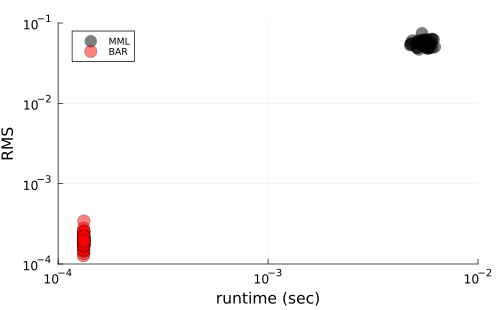

In [3]:
plot(xlabel="runtime (sec)", ylabel="RMS", xscale=:log10, yscale=:log10, legend=:topleft, margin=18Plots.pt)
scatter!(times_GP,  RMS_GP, markersize=10, alpha=0.5, color="black", label="MML")
scatter!(times_AR1, RMS_AR1, markersize=10, alpha=0.5,  color="red", label="BAR")
plot!(ylims=(1e-4,1e-1), xlims=(1e-4, 1e-2), guidefontsize=15, tickfontsize=12,)

In [4]:
savefig("figures/experiment-AR1-RMS.pdf")

"/home/synd/Wouter/Onderzoek/Projecten/tue/tgp-hopt-ar/hopt-bar/mc-experiments/figures/experiment-AR1-RMS.pdf"

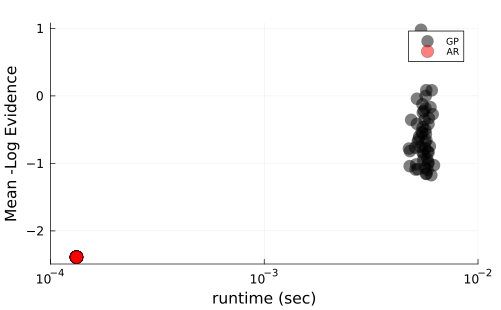

In [49]:
plot(xlabel="runtime (sec)", ylabel="Mean -Log Evidence", xscale=:log10, legend=:topright, margin=18Plots.pt)
scatter!(times_GP,  NLE_GP, markersize=10, alpha=0.5, color="black", label="GP")
scatter!(times_AR1, NLE_AR1, markersize=10, alpha=0.5,  color="red", label="AR")
plot!(xlims=(1e-4, 1e-2), guidefontsize=15, tickfontsize=12,)

In [ ]:
savefig("figures/experiment-AR1-NLE.pdf")

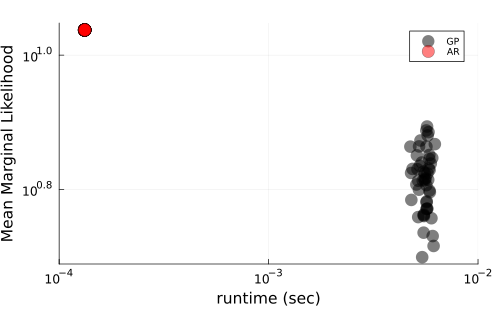

In [44]:
plot(xlabel="runtime (sec)", ylabel="Mean Marginal Likelihood", xscale=:log10, yscale=:log10, legend=:topright, margin=18Plots.pt)
scatter!(times_GP,  MML_GP, markersize=10, alpha=0.5, color="black", label="GP")
scatter!(times_AR1, MML_AR1, markersize=10, alpha=0.5,  color="red", label="AR")
plot!(xlims=(1e-4, 1e-2), guidefontsize=15, tickfontsize=12,)

In [45]:
savefig("figures/experiment-AR1-MLL.pdf")

"c:\\Syndr\\Wouter\\Onderzoek\\Projecten\\tue\\tgp-hopt-ar\\hopt-bar\\mc-experiments\\figures\\experiment-AR1-MLL.pdf"